# 03 — Treinamento e Comparação de Modelos
**BOVA11 ML Pipeline**

Objetivo: treinar e comparar XGBoost, LightGBM e XGBoost+Optuna em validação walk-forward.

---

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import optuna
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Pronto.')

Pronto.


In [8]:
df = pd.read_parquet('../data/processed/bova11_features.parquet')

meta_cols = ['open','high','low','close','volume','retorno','target',
             'mes','dia_semana']
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols]
y = df['target']

print(f'Features: {len(feature_cols)} | Amostras: {len(y)}')

Features: 29 | Amostras: 2260


## 1. Split temporal (sem data leakage)

In [9]:
# 70% treino | 15% validação | 15% teste — respeitando ordem temporal
n = len(X)
i_val  = int(n * 0.70)
i_test = int(n * 0.85)

X_train, y_train = X.iloc[:i_val],   y.iloc[:i_val]
X_val,   y_val   = X.iloc[i_val:i_test], y.iloc[i_val:i_test]
X_test,  y_test  = X.iloc[i_test:],  y.iloc[i_test:]

print(f'Treino:    {len(X_train):,} ({X_train.index[0].date()} → {X_train.index[-1].date()})')
print(f'Validação: {len(X_val):,}  ({X_val.index[0].date()} → {X_val.index[-1].date()})')
print(f'Teste:     {len(X_test):,}  ({X_test.index[0].date()} → {X_test.index[-1].date()})')

Treino:    1,582 (2015-10-23 → 2022-04-13)
Validação: 339  (2022-04-14 → 2023-08-21)
Teste:     339  (2023-08-22 → 2024-12-30)


## 2. XGBoost baseline

In [10]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)

pred_xgb  = xgb_model.predict(X_test)
prob_xgb  = xgb_model.predict_proba(X_test)[:, 1]
acc_xgb   = accuracy_score(y_test, pred_xgb)
auc_xgb   = roc_auc_score(y_test, prob_xgb)

print(f'XGBoost — Acurácia: {acc_xgb:.4f} | AUC-ROC: {auc_xgb:.4f}')

XGBoost — Acurácia: 0.5015 | AUC-ROC: 0.5009


## 3. LightGBM

In [11]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(-1)])

pred_lgb  = lgb_model.predict(X_test)
prob_lgb  = lgb_model.predict_proba(X_test)[:, 1]
acc_lgb   = accuracy_score(y_test, pred_lgb)
auc_lgb   = roc_auc_score(y_test, prob_lgb)

print(f'LightGBM — Acurácia: {acc_lgb:.4f} | AUC-ROC: {auc_lgb:.4f}')

LightGBM — Acurácia: 0.5015 | AUC-ROC: 0.5313


## 4. XGBoost + Optuna (hyperparameter tuning)

In [12]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 1),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'random_state': 42, 'eval_metric': 'logloss', 'verbosity': 0
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                 verbose=False)
    pred = model.predict(X_val)
    return accuracy_score(y_val, pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best = study.best_params
print(f'\nMelhores params: {best}')
print(f'Melhor acurácia (val): {study.best_value:.4f}')

  0%|          | 0/50 [00:00<?, ?it/s]


Melhores params: {'n_estimators': 551, 'learning_rate': 0.08941816232466619, 'max_depth': 6, 'subsample': 0.7445148289711001, 'colsample_bytree': 0.536117173793434, 'min_child_weight': 10, 'gamma': 0.20336467828834415, 'reg_alpha': 0.0015599353266459335, 'reg_lambda': 0.0036284331464510222}
Melhor acurácia (val): 0.5487


In [13]:
xgb_opt = xgb.XGBClassifier(**best, random_state=42, verbosity=0)
xgb_opt.fit(X_train, y_train)

pred_opt = xgb_opt.predict(X_test)
prob_opt = xgb_opt.predict_proba(X_test)[:, 1]
acc_opt  = accuracy_score(y_test, pred_opt)
auc_opt  = roc_auc_score(y_test, prob_opt)

print(f'XGBoost+Optuna — Acurácia: {acc_opt:.4f} | AUC-ROC: {auc_opt:.4f}')

XGBoost+Optuna — Acurácia: 0.5516 | AUC-ROC: 0.5602


## 5. Comparação de modelos

        Modelo  Acurácia  AUC-ROC
XGBoost+Optuna    0.5516   0.5602
       XGBoost    0.5015   0.5009
      LightGBM    0.5015   0.5313


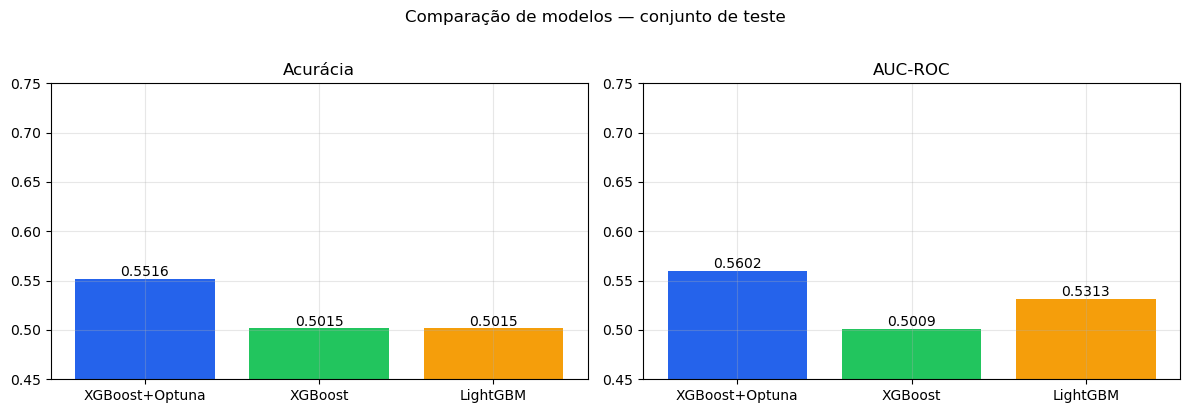

In [14]:
resultados = pd.DataFrame({
    'Modelo':    ['XGBoost', 'LightGBM', 'XGBoost+Optuna'],
    'Acurácia':  [acc_xgb,   acc_lgb,    acc_opt],
    'AUC-ROC':   [auc_xgb,   auc_lgb,    auc_opt],
})
resultados = resultados.sort_values('Acurácia', ascending=False).reset_index(drop=True)

print(resultados.to_string(index=False, float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cores = ['#2563eb', '#22c55e', '#f59e0b']

for i, (metric, ax) in enumerate(zip(['Acurácia', 'AUC-ROC'], axes)):
    bars = ax.bar(resultados['Modelo'], resultados[metric], color=cores)
    ax.set_title(metric)
    ax.set_ylim(0.45, 0.75)
    for bar, val in zip(bars, resultados[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontsize=10)

plt.suptitle('Comparação de modelos — conjunto de teste', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature importance (melhor modelo)

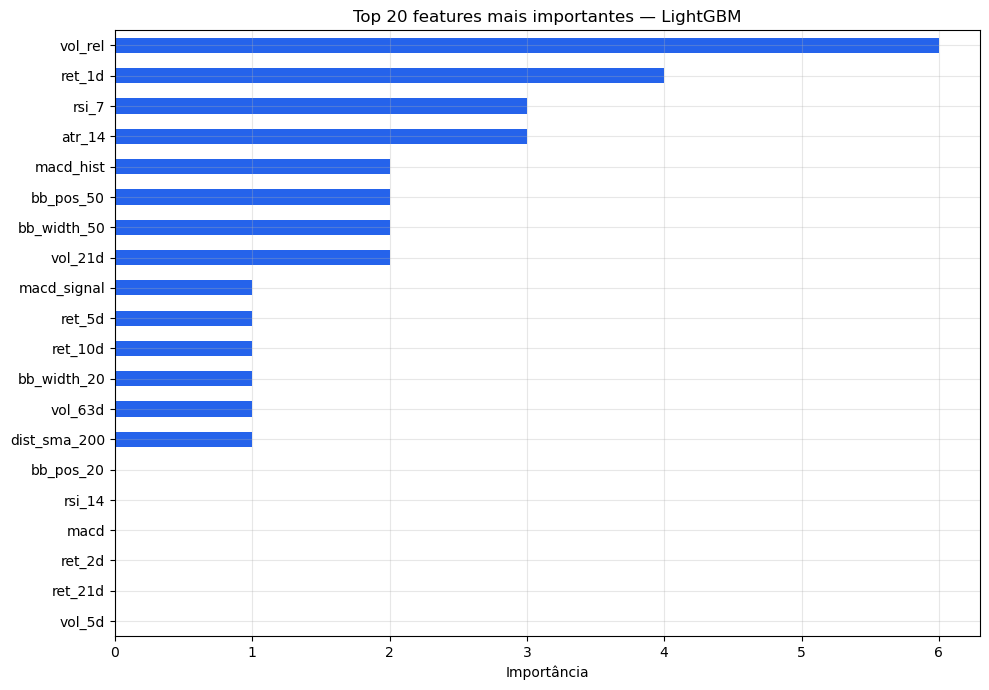

In [15]:
importances = pd.Series(lgb_model.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color='#2563eb')
ax.set_title('Top 20 features mais importantes — LightGBM')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Salvar modelos

In [16]:
import joblib, os
os.makedirs('../models', exist_ok=True)

joblib.dump(lgb_model,  '../models/lightgbm_final.pkl')
joblib.dump(xgb_opt,    '../models/xgboost_optuna.pkl')
joblib.dump(feature_cols, '../models/feature_cols.pkl')

print('Modelos salvos em /models/')
print('Próximo passo → 04_backtest.ipynb')

Modelos salvos em /models/
Próximo passo → 04_backtest.ipynb
